In [ ]:
!pip install wptools

In [ ]:
!pip install mwparserfromhell

In [ ]:
!pip install levenshtein

In [ ]:
!pip install cairosvg

In [ ]:
try:
    import cairosvg

    CAIROSVG_AVAILABLE = True
except ImportError:
    CAIROSVG_AVAILABLE = False
    # logger.warning("cairosvg не установлен. SVG-подписи будут пропущены. Установите: pip install cairosvg")

In [ ]:
VALID_USER_AGENTS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.1 Safari/605.1.15",
    "Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:109.0) Gecko/20100101 Firefox/121.0",
    "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36 Edg/120.0.0.0",
    "Mozilla/5.0 (iPhone; CPU iPhone OS 17_1_1 like Mac OS X) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/17.1 Mobile/15E148 Safari/604.1",
]

In [ ]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-

import os
import csv
import argparse
import logging
import time
import random
import sys
from urllib.parse import unquote
from pathlib import Path
from typing import List, Dict, Optional
import re
import math

import requests
import wptools
from PIL import Image as PILImage
import Levenshtein

try:
    import cairosvg

    CAIROSVG_AVAILABLE = True
except ImportError:
    CAIROSVG_AVAILABLE = False
    logging.warning("cairosvg не установлен. SVG-подписи будут пропущены. Установите: pip install cairosvg")

"""
Wikipedia Signature Downloader
==============================
Этот скрипт загружает изображения подписей известных личностей из Википедии.
Он может работать как по предоставленному списку имён (с возможностью приблизительного поиска),
так и случайным образом, исследуя граф ссылок Википедии.

Новые возможности:
- В режиме DFS в CSV попадают только персоны с найденной подписью.
- При выборе следующей ссылки используется взвешенная вероятность,
  предпочитающая страницы с пробелом в названии и заглавными буквами в словах.
- Управление "отжигом" через параметр --temperature.
- Корректный User-Agent и обработка 429 согласно политике Wikimedia.
"""

# ---------- Глобальные настройки бота (ЗАМЕНИТЕ НА СВОИ) ----------
BOT_NAME = "SignatureDownloaderResearchBot"
BOT_VERSION = "1.0"
### ПОменять на реальную почту, могут блокировать:
BOT_CONTACT = "adress@example.com"

# -----------------------------------------------------------------

# Список User-Agent с указанием бота (разные браузеры для ротации)
VALID_USER_AGENTS = [
    f"{BOT_NAME}/{BOT_VERSION} ({BOT_CONTACT}) Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36",
    f"{BOT_NAME}/{BOT_VERSION} ({BOT_CONTACT}) Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.0 Safari/605.1.15",
    f"{BOT_NAME}/{BOT_VERSION} ({BOT_CONTACT}) Mozilla/5.0 (X11; Linux x86_64; rv:109.0) Gecko/20100101 Firefox/115.0",
]

logging.basicConfig(level=logging.INFO, format="%(asctime)s - %(levelname)s - %(message)s", datefmt="%Y-%m-%d %H:%M:%S")
logger = logging.getLogger(__name__)


class WikipediaSignatureDownloader:
    """Основной класс для загрузки подписей из Википедии."""

    def __init__(
        self,
        output_dir: str = "signatures",
        output_format: str = "png",
        max_pages: int = 100,
        delay: float = 2.0,
        lang: str = "en",
        temperature: float = 1.0,
        rotate_every: int = 0,
        thumb_width: int = 500,
    ):
        """
        Инициализация загрузчика.

        Args:
            output_dir: Корневая директория для сохранения результатов.
            output_format: Формат изображений ('png' или 'jpeg').
            max_pages: Максимальное количество страниц для обхода (при случайном поиске).
            delay: Задержка между запросами к API (в секундах). Рекомендуется >= 2.
            lang: Языковой раздел Википедии (по умолчанию 'en').
            temperature: Температура для вероятностного выбора ссылок (чем выше, тем равномернее).
            rotate_every: Частота смены User-Agent (0 - без ротации).
            thumb_width: Ширина thumbnail для скачиваемых изображений (0 - оригинал).
        """
        self.output_dir = Path(output_dir)
        self.output_format = output_format.lower()
        self.max_pages = max_pages
        self.delay = delay
        self.lang = lang
        self.temperature = temperature
        self.rotate_every = rotate_every
        self.thumb_width = thumb_width

        self.images_dir = self.output_dir / f"images_{self.output_format}"
        self.images_dir.mkdir(parents=True, exist_ok=True)
        self.csv_file = self.output_dir / "signatures.csv"

        self.processed_pages = 0
        self.downloaded_signatures = 0
        self.page_counter = 0

        # Инициализация заголовков
        self._update_headers()

    def _update_headers(self):
        """Случайная смена User-Agent из пула валидных."""
        self.headers = {"User-Agent": random.choice(VALID_USER_AGENTS), "Accept-Encoding": "gzip"}
        logger.info(f"User-Agent установлен: {self.headers['User-Agent']}")

    def _maybe_rotate_headers(self):
        """Увеличивает счётчик страниц и при необходимости меняет заголовки."""
        self.page_counter += 1
        if self.rotate_every > 0 and self.page_counter % self.rotate_every == 0:
            self._update_headers()

    def _request_with_retry(self, method: str, url: str, **kwargs) -> requests.Response:
        """
        Выполняет HTTP-запрос с обработкой 429 и автоматическим повтором.
        """
        max_retries = 5
        for attempt in range(max_retries):
            try:
                response = requests.request(method, url, headers=self.headers, timeout=15, **kwargs)
                if response.status_code == 429:
                    retry_after = response.headers.get("Retry-After")
                    if retry_after is not None:
                        wait = int(retry_after)
                        logger.warning(f"Ошибка 429. Ожидание {wait} сек согласно Retry-After.")
                    else:
                        wait = 5 * (attempt + 1)
                        logger.warning(f"Ошибка 429. Retry-After отсутствует, ждём {wait} сек.")
                    time.sleep(wait)
                    continue
                response.raise_for_status()
                return response
            except requests.exceptions.RequestException as e:
                if attempt == max_retries - 1:
                    raise
                wait = 2**attempt
                logger.warning(f"Ошибка запроса: {e}. Повтор через {wait} сек.")
                time.sleep(wait)
        raise RuntimeError(f"Не удалось выполнить запрос после {max_retries} попыток: {url}")

    def _sanitize_filename(self, name: str) -> str:
        """Приводит имя к безопасному имени файла (латиница, цифры, подчёркивания)."""
        name = re.sub(r"[^À-῿Ⰰ-퟿぀-ヿㇰ-ㇿ㈀-㋿㌀-㏿一-鿿豈-﫿＀-￯\w\s-]", "", name)
        name = re.sub(r"[\s]+", "_", name)
        return name

    def _get_wikipedia_page(self, title: str) -> Optional[wptools.page]:
        """Получает объект страницы Википедии."""
        try:
            page = wptools.page(title, lang=self.lang, silent=True)
            page.get_parse()
            return page
        except Exception as e:
            logger.error(f"Ошибка при получении страницы '{title}': {e}")
            return None

    def _extract_signature_from_infobox(self, page: wptools.page) -> Optional[str]:
        """Извлекает URL или имя файла подписи из инфобокса."""
        infobox = page.data.get("infobox", {})
        if not infobox:
            return None

        signature_key = None
        for key in infobox.keys():
            if "signature" in key.lower():
                signature_key = key
                break

        if not signature_key:
            return None

        signature_value = infobox[signature_key]
        if not signature_value:
            return None

        if isinstance(signature_value, str):
            return signature_value
        elif isinstance(signature_value, dict):
            return signature_value.get("file") or signature_value.get("url")
        return None

    def _get_image_url(self, file_name: str) -> Optional[str]:
        """
        Получает прямую ссылку на изображение по имени файла.
        Если задан thumb_width > 0, возвращает URL уменьшенной копии (thumbnail).
        """
        file_name = file_name.strip()
        file_name = re.sub(r"^(File:|Image:)\s*", "", file_name, flags=re.IGNORECASE)

        api_url = f"https://{self.lang}.wikipedia.org/w/api.php"
        params = {
            "action": "query",
            "titles": f"File:{file_name}",
            "prop": "imageinfo",
            "iiprop": "url",
            "format": "json",
        }
        if self.thumb_width > 0:
            params["iiurlwidth"] = self.thumb_width

        try:
            response = self._request_with_retry("GET", api_url, params=params)
            data = response.json()
            pages = data.get("query", {}).get("pages", {})
            for page_id, page_data in pages.items():
                imageinfo = page_data.get("imageinfo", [])
                if imageinfo:
                    info = imageinfo[0]
                    if self.thumb_width > 0 and "thumburl" in info:
                        return info["thumburl"]
                    else:
                        return info["url"]
            return None
        except Exception as e:
            logger.error(f"Ошибка при получении URL для '{file_name}': {e}")
            return None

    def _download_image(self, url: str, destination: Path) -> bool:
        """Скачивает изображение по URL."""
        try:
            # Небольшая случайная задержка, чтобы снизить пиковую нагрузку
            time.sleep(random.uniform(0.5, 1.0))
            response = self._request_with_retry("GET", url, stream=True)
            with open(destination, "wb") as f:
                for chunk in response.iter_content(chunk_size=8192):
                    f.write(chunk)
            return True
        except Exception as e:
            logger.error(f"Ошибка при скачивании изображения с {url}: {e}")
            return False

    def _convert_image_format(self, src_path: Path, dst_path: Path) -> bool:
        """
        Конвертирует изображение в нужный формат (PNG или JPEG).
        Поддерживает SVG через cairosvg.
        """
        ext = src_path.suffix.lower()

        # Обработка SVG
        if ext == ".svg":
            if not CAIROSVG_AVAILABLE:
                logger.error(f"SVG-файл {src_path} не может быть конвертирован: cairosvg не установлен.")
                return False
            try:
                if self.output_format == "png":
                    cairosvg.svg2png(url=str(src_path), write_to=str(dst_path))
                    return True
                elif self.output_format == "jpeg":
                    temp_png = dst_path.with_suffix(".png")
                    cairosvg.svg2png(url=str(src_path), write_to=str(temp_png))
                    with PILImage.open(temp_png) as img:
                        if img.mode in ("RGBA", "LA", "P"):
                            background = PILImage.new("RGB", img.size, (255, 255, 255))
                            background.paste(img, mask=img.split()[-1] if img.mode == "RGBA" else None)
                            img = background
                        elif img.mode != "RGB":
                            img = img.convert("RGB")
                        img.save(dst_path, format="JPEG")
                    temp_png.unlink()
                    return True
            except Exception as e:
                logger.error(f"Ошибка при конвертации SVG {src_path}: {e}")
                return False

        # Обработка растровых изображений
        try:
            with PILImage.open(src_path) as img:
                if self.output_format == "jpeg" and img.mode in ("RGBA", "LA", "P"):
                    background = PILImage.new("RGB", img.size, (255, 255, 255))
                    background.paste(img, mask=img.split()[-1] if img.mode == "RGBA" else None)
                    img = background
                elif self.output_format == "jpeg" and img.mode != "RGB":
                    img = img.convert("RGB")

                img.save(dst_path, format=self.output_format.upper())
            return True
        except Exception as e:
            logger.error(f"Ошибка при конвертации {src_path} в {self.output_format}: {e}")
            return False

    def process_person(self, name: str) -> Optional[str]:
        """Обрабатывает одну персону, возвращает имя файла подписи или None."""
        logger.info(f"Обработка: {name}")

        page = self._get_wikipedia_page(name)
        if not page:
            return None

        signature_file = self._extract_signature_from_infobox(page)
        if not signature_file:
            logger.warning(f"Подпись не найдена для {name}")
            return None

        image_url = self._get_image_url(signature_file)
        if not image_url:
            logger.warning(f"Не удалось получить URL для подписи: {signature_file}")
            return None

        safe_name = self._sanitize_filename(name)
        original_ext = os.path.splitext(unquote(image_url.split("/")[-1]))[1]
        if not original_ext:
            original_ext = ".jpg"

        temp_file = self.images_dir / f"temp_{safe_name}{original_ext}"
        final_file = self.images_dir / f"{safe_name}.{self.output_format}"

        if not self._download_image(image_url, temp_file):
            return None

        success = self._convert_image_format(temp_file, final_file)
        if temp_file.exists():
            temp_file.unlink()

        if not success:
            return None

        logger.info(f"✓ Подпись сохранена: {final_file.name}")
        self.downloaded_signatures += 1
        self._maybe_rotate_headers()

        return final_file.name

    def save_to_csv(self, records: List[Dict[str, str]]):
        """Сохраняет записи в CSV-файл."""
        file_exists = self.csv_file.exists()
        with open(self.csv_file, "a", newline="", encoding="utf-8") as csvfile:
            writer = csv.DictWriter(csvfile, fieldnames=["name", "img"], delimiter="|")
            if not file_exists:
                writer.writeheader()
            writer.writerows(records)

    def run_by_name_list(self, names: List[str], fuzzy: bool = False, threshold: float = 0.8):
        """Обрабатывает предоставленный список имён."""
        records = []
        for name in names:
            if self.processed_pages >= self.max_pages:
                break

            if fuzzy:
                best_match = self._fuzzy_search_wikipedia(name, threshold)
                if best_match:
                    logger.info(f"Нечёткое совпадение: '{name}' -> '{best_match}'")
                    name = best_match
                else:
                    logger.warning(f"Не найдено подходящего совпадения для '{name}'")
                    continue

            img_file = self.process_person(name)
            records.append({"name": name, "img": img_file if img_file else ""})
            self.processed_pages += 1
            time.sleep(self.delay)

        self.save_to_csv(records)
        logger.info(f"Обработано персон: {self.processed_pages}, загружено подписей: {self.downloaded_signatures}")

    def _fuzzy_search_wikipedia(self, query: str, threshold: float) -> Optional[str]:
        """Нечёткий поиск по Википедии с расстоянием Левенштейна."""
        api_url = f"https://{self.lang}.wikipedia.org/w/api.php"
        params = {"action": "query", "list": "search", "srsearch": query, "srlimit": 10, "format": "json"}
        try:
            response = self._request_with_retry("GET", api_url, params=params)
            data = response.json()
            search_results = data.get("query", {}).get("search", [])

            if not search_results:
                return None

            best_ratio = 0.0
            best_title = None
            for result in search_results:
                title = result["title"]
                max_len = max(len(query), len(title))
                if max_len == 0:
                    continue
                ratio = 1.0 - (Levenshtein.distance(query.lower(), title.lower()) / max_len)
                if ratio > best_ratio and ratio >= threshold:
                    best_ratio = ratio
                    best_title = title

            return best_title
        except Exception as e:
            logger.error(f"Ошибка при нечётком поиске для '{query}': {e}")
            return None

    def _link_score(self, title: str) -> float:
        """
        Вычисляет оценку "похожести на персону" для названия статьи.
        Критерии:
          - Наличие пробела (имя + фамилия) добавляет 1.0.
          - Если каждое слово начинается с заглавной буквы (и не содержит заглавных внутри), добавляет 2.0.
          - Вычитает 2.0, если содержит числа/цифры, не являющиеся порядковыми (например, "14th" или "Second" не штрафуются).
        """
        score = 0.0

        if " " in title:
            score += 1.0

        original_words = title.split()
        if original_words and all(w[0].isupper() and w[1:].islower() for w in original_words if w):
            score += 2.0

        lower_title = title.lower()
        if re.search(r"\d", lower_title):
            if re.search(r"\b\d+(?!(?:st|nd|rd|th)\b)", lower_title):
                score -= 2.0

        return score

    def _select_next_links(self, links: List[str], count: int) -> List[str]:
        """
        Выбирает `count` ссылок из списка с вероятностями, пропорциональными exp(score / temperature).
        Используется "отжиг": чем выше temperature, тем более равновероятен выбор.
        """
        if not links:
            return []

        scores = [self._link_score(link) for link in links]
        max_score = max(scores)
        exp_scores = [math.exp((s - max_score) / self.temperature) for s in scores]
        total = sum(exp_scores)
        probs = [e / total for e in exp_scores]

        selected = []
        indices = list(range(len(links)))
        for _ in range(min(count, len(links))):
            if not indices:
                break
            remaining_probs = [probs[i] for i in indices]
            sum_rem = sum(remaining_probs)
            if sum_rem == 0:
                chosen_idx = random.choice(indices)
            else:
                norm_probs = [p / sum_rem for p in remaining_probs]
                chosen_idx = random.choices(indices, weights=norm_probs, k=1)[0]
            selected.append(links[chosen_idx])
            indices.remove(chosen_idx)
        return selected

    def _get_page_links(self, title: str, limit: int = 20) -> List[str]:
        """Возвращает список ссылок на другие статьи Википедии."""
        api_url = f"https://{self.lang}.wikipedia.org/w/api.php"
        params = {
            "action": "query",
            "titles": title,
            "prop": "links",
            "plnamespace": 0,
            "pllimit": limit,
            "format": "json",
        }
        try:
            response = self._request_with_retry("GET", api_url, params=params)
            data = response.json()
            pages = data.get("query", {}).get("pages", {})
            links = []
            for page_id, page_data in pages.items():
                if "links" in page_data:
                    links.extend([link["title"] for link in page_data["links"]])
            return links
        except Exception as e:
            logger.error(f"Ошибка при получении ссылок для '{title}': {e}")
            return []

    def run_random_dfs(self, start_title: str = "Albert_Einstein", max_depth: int = 3):
        """
        Случайный обход Википедии методом DFS с приоритизацией страниц-персон.
        В CSV попадают только страницы, для которых найдена подпись.
        """
        visited = set()
        stack = [(start_title, 0)]
        records = []

        while stack and self.processed_pages < self.max_pages:
            title, depth = stack.pop()
            if title in visited or depth > max_depth:
                continue
            visited.add(title)

            logger.info(f"DFS посещение: {title} (глубина {depth})")
            img_file = self.process_person(title)
            self.processed_pages += 1

            if img_file:
                records.append({"name": title, "img": img_file})
                logger.info(f"Запись добавлена в CSV: {title}")
            else:
                logger.info(f"Подпись не найдена, пропускаем запись: {title}")

            time.sleep(self.delay)

            if depth < max_depth and self.processed_pages < self.max_pages:
                links = self._get_page_links(title)
                if links:
                    selected = self._select_next_links(links, count=10)
                    random.shuffle(selected)
                    for link in selected:
                        if link not in visited:
                            stack.append((link, depth + 1))

        if records:
            self.save_to_csv(records)
        else:
            logger.warning("Нет записей с подписями для сохранения.")
        logger.info(
            f"Обход завершён. Обработано страниц: {self.processed_pages}, подписей: {self.downloaded_signatures}"
        )


def parse_arguments():
    parser = argparse.ArgumentParser(description="Загрузчик подписей из Википедии")
    parser.add_argument("--names", nargs="+", help="Список имён для обработки")
    parser.add_argument("--file", type=str, help="Файл со списком имён (по одному на строку)")
    parser.add_argument("--fuzzy", action="store_true", help="Включить нечёткий поиск для имён")
    parser.add_argument("--threshold", type=float, default=0.8, help="Порог схожести для нечёткого поиска (0.0-1.0)")
    parser.add_argument(
        "--format",
        type=str,
        choices=["png", "jpeg"],
        default="png",
        help="Формат сохраняемых изображений (по умолчанию png)",
    )
    parser.add_argument("--max-pages", type=int, default=100, help="Максимальное количество обрабатываемых страниц")
    parser.add_argument(
        "--dfs", action="store_true", help="Использовать случайный обход методом DFS вместо списка имён"
    )
    parser.add_argument("--start", type=str, default="Albert_Einstein", help="Начальная статья для DFS обхода")
    parser.add_argument("--depth", type=int, default=3, help="Максимальная глубина для DFS обхода")
    parser.add_argument(
        "--delay", type=float, default=2.0, help="Задержка между запросами в секундах (рекомендуется >=2)"
    )
    parser.add_argument("--lang", type=str, default="en", help="Языковой код Википедии (например, 'en', 'ru', 'de')")
    parser.add_argument("--output", type=str, default="signatures", help="Корневая директория для вывода")
    parser.add_argument(
        "--temperature",
        type=float,
        default=1.0,
        help="Температура для вероятностного выбора ссылок (0.1 - почти детерминировано, 5.0 - почти равномерно)",
    )
    parser.add_argument(
        "--rotate-every", type=int, default=0, help="Частота смены User-Agent (количество страниц). 0 — без ротации."
    )
    parser.add_argument(
        "--thumb-width",
        type=int,
        default=500,
        help="Ширина thumbnail для скачиваемых изображений (0 - оригинал). По умолчанию 500.",
    )

    return parser.parse_args()


def main():
    args = parse_arguments()

    downloader = WikipediaSignatureDownloader(
        output_dir=args.output,
        output_format=args.format,
        max_pages=args.max_pages,
        delay=args.delay,
        lang=args.lang,
        temperature=args.temperature,
        rotate_every=args.rotate_every,
        thumb_width=args.thumb_width,
    )

    if args.dfs:
        logger.info(
            f"Запуск случайного обхода DFS, начиная с '{args.start}' (макс. страниц: {args.max_pages}, температура: {args.temperature})"
        )
        downloader.run_random_dfs(start_title=args.start, max_depth=args.depth)
    else:
        names = []
        if args.names:
            names.extend(args.names)
        if args.file:
            with open(args.file, "r", encoding="utf-8") as f:
                names.extend([line.strip() for line in f if line.strip()])

        if not names:
            logger.error("Не указаны имена для обработки. Используйте --names, --file или --dfs.")
            sys.exit(1)

        logger.info(f"Начинаем обработку {len(names)} персон (макс. страниц: {args.max_pages})")
        downloader.run_by_name_list(names, fuzzy=args.fuzzy, threshold=args.threshold)

    logger.info("Готово!")


# if __name__ == "__main__":
#    main()

In [ ]:
!rm -r ./sigscr_dir_imporved_random

In [ ]:
downloader_improved = WikipediaSignatureDownloader(
    output_dir="sigscr_dir_imporved_random",
    output_format="png",
    max_pages=1000,
    delay=1.0,
    lang="en",
    temperature=3.5,
    rotate_every=7,
    thumb_width=512,
)

In [ ]:
list_of_persons = [
    "Viktor_Tsoi",
    "Vladimir_Vysotsky",
    "Johnny_Depp",
    "14th_Dalai_Lama",
    "Yuri_Gagarin",
    "Quentin_Tarantino",
    "Donald_Trump",
    "Robert_F._Kennedy",
    "Joseph_McCarthy",
    "Douglas_MacArthur",
    "Nicholas_I_of_Russia",
    "Alexander_I_of_Russia",
    "Alexander_II_of_Russia",
    "Alexander_III_of_Russia",
    "Abraham_Lincoln",
    "Boris_Yeltsin",
    "Wernher_von_Braun",
    "Konstantin_Tsiolkovsky",
    "Anton_Chekhov",
    "Fyodor_Dostoevsky",
    "Mikhail_Bulgakov",
    "Henry_Ford",
    "Ferdinand_Porsche",
    "J._Robert_Oppenheimer",
    "Elon_Musk",
    "Kurt_Cobain",
    "John_Lennon",
    "Paul_McCartney",
    "Leon_Trotsky",
    "Pyotr_Wrangel",
    "Andrei_Tupolev",
    "William_E._Boeing",
    "Nikolay_Zhukovsky_(scientist)",
    "Pafnuty_Chebyshev",
    "Carl_Gustaf_Emil_Mannerheim",
    "Georgy_Zhukov",
    "J._R._R._Tolkien",
    "Nikolai_Gogol",
    "Neil_Armstrong",
    "Ozzy_Osbourne",
]

In [ ]:
print(f"Len of list: {len(list_of_persons)}")

Len of list: 40


In [ ]:
downloader_improved.run_by_name_list(list_of_persons)

In [ ]:
!ls -la

total 20
drwxr-xr-x 1 root root 4096 Apr 17 13:56 .
drwxr-xr-x 1 root root 4096 Apr 17 12:03 ..
drwxr-xr-x 4 root root 4096 Apr  2 13:31 .config
drwxr-xr-x 1 root root 4096 Apr  2 13:31 sample_data
drwxr-xr-x 3 root root 4096 Apr 17 13:58 sigscr_dir_imporved_random


In [ ]:
!zip -r ./signatures_set.zip ./sigscr_dir_imporved_random

  adding: sigscr_dir_imporved_random/ (stored 0%)
  adding: sigscr_dir_imporved_random/images_png/ (stored 0%)
  adding: sigscr_dir_imporved_random/images_png/Ozzy_Osbourne.png (deflated 2%)
  adding: sigscr_dir_imporved_random/images_png/Ferdinand_Porsche.png (deflated 1%)
  adding: sigscr_dir_imporved_random/images_png/Alexander_III_of_Russia.png (deflated 11%)
  adding: sigscr_dir_imporved_random/images_png/14th_Dalai_Lama.png (deflated 2%)
  adding: sigscr_dir_imporved_random/images_png/Georgy_Zhukov.png (deflated 3%)
  adding: sigscr_dir_imporved_random/images_png/Quentin_Tarantino.png (deflated 2%)
  adding: sigscr_dir_imporved_random/images_png/Pafnuty_Chebyshev.png (deflated 0%)
  adding: sigscr_dir_imporved_random/images_png/Nikolai_Gogol.png (deflated 1%)
  adding: sigscr_dir_imporved_random/images_png/Douglas_MacArthur.png (deflated 2%)
  adding: sigscr_dir_imporved_random/images_png/Konstantin_Tsiolkovsky.png (deflated 1%)
  adding: sigscr_dir_imporved_random/images_png/J_R

In [ ]:
from google.colab import files

files.download("./signatures_set.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv("sigscr_dir_imporved_random/signatures.csv", sep="|")

In [ ]:
data

,name,img
0,Viktor_Tsoi,Viktor_Tsoi.png
1,Vladimir_Vysotsky,Vladimir_Vysotsky.png
2,Johnny_Depp,Johnny_Depp.png
3,14th_Dalai_Lama,14th_Dalai_Lama.png
4,Yuri_Gagarin,Yuri_Gagarin.png
5,Quentin_Tarantino,Quentin_Tarantino.png
6,Donald_Trump,Donald_Trump.png
7,Robert_F._Kennedy,Robert_F_Kennedy.png
8,Joseph_McCarthy,Joseph_McCarthy.png
9,Douglas_MacArthur,Douglas_MacArthur.png


Displaying signatures:

Viktor_Tsoi:


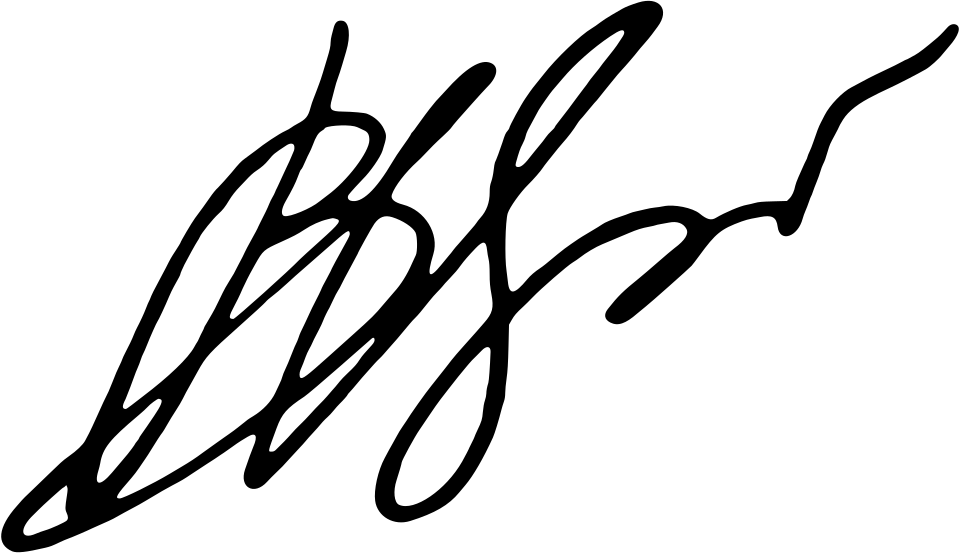


Vladimir_Vysotsky:


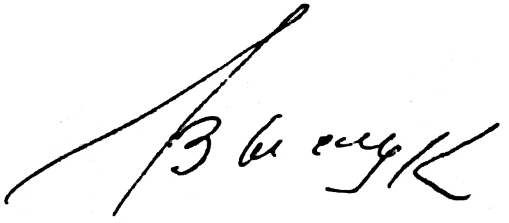


Johnny_Depp:


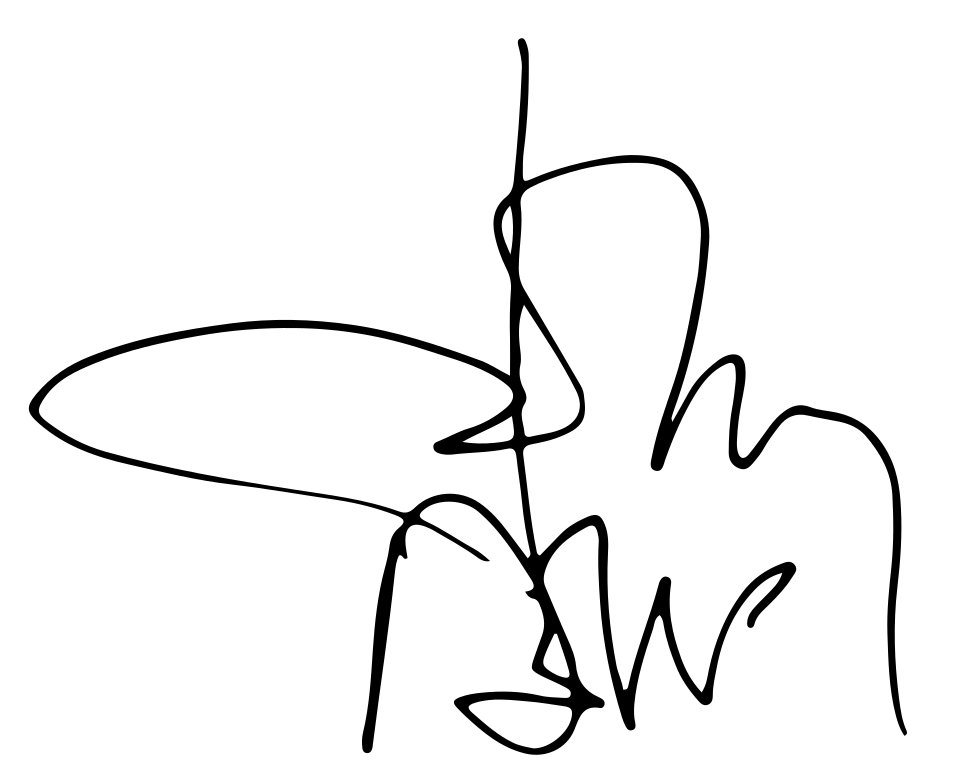


14th_Dalai_Lama:


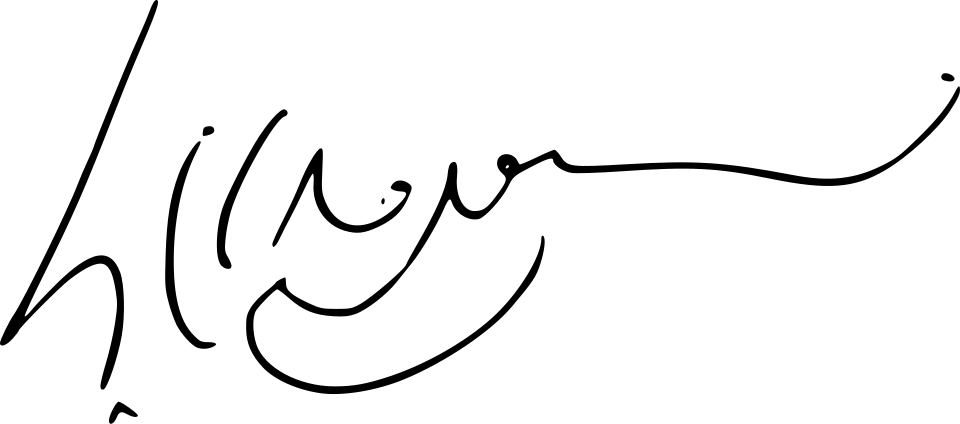


Yuri_Gagarin:


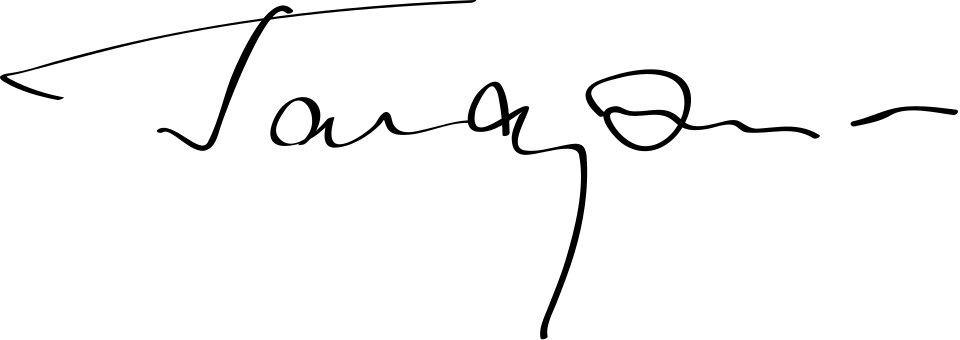


Quentin_Tarantino:


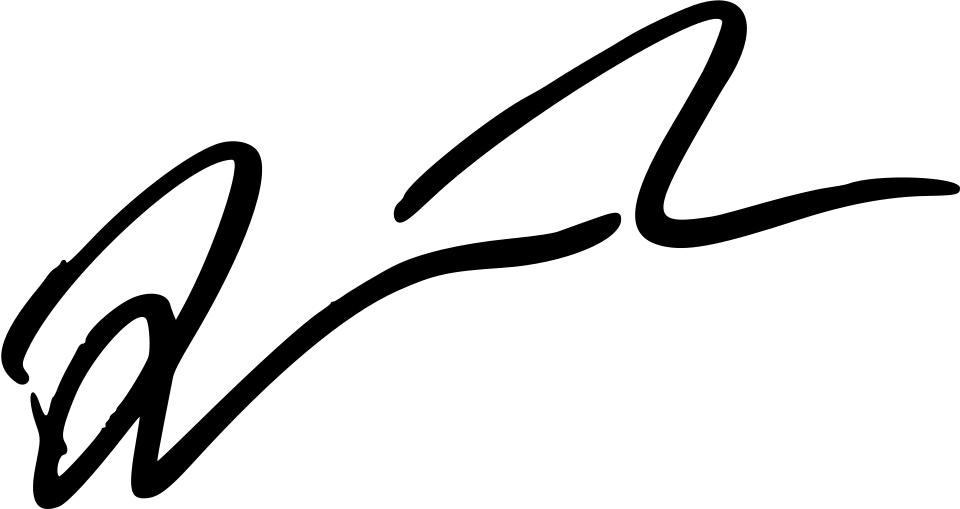


Donald_Trump:


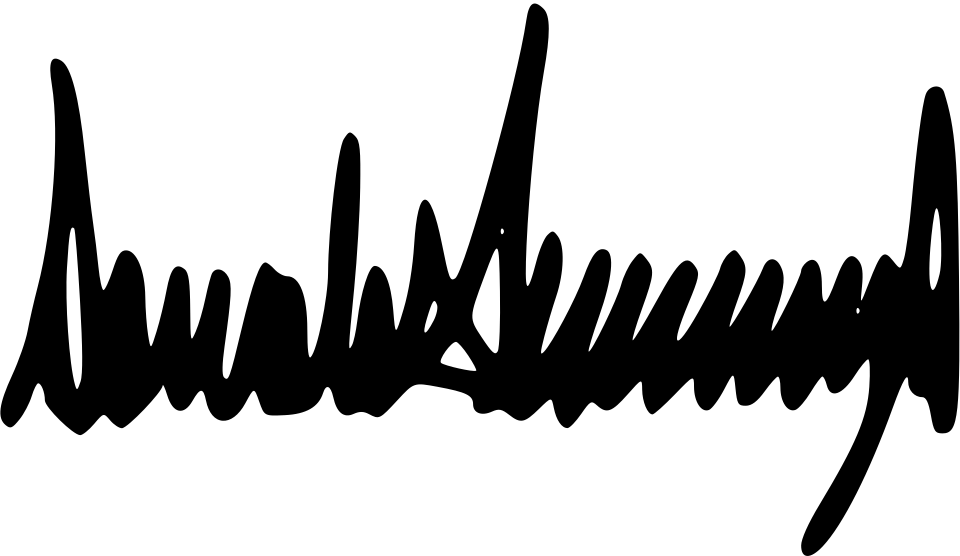


Robert_F._Kennedy:


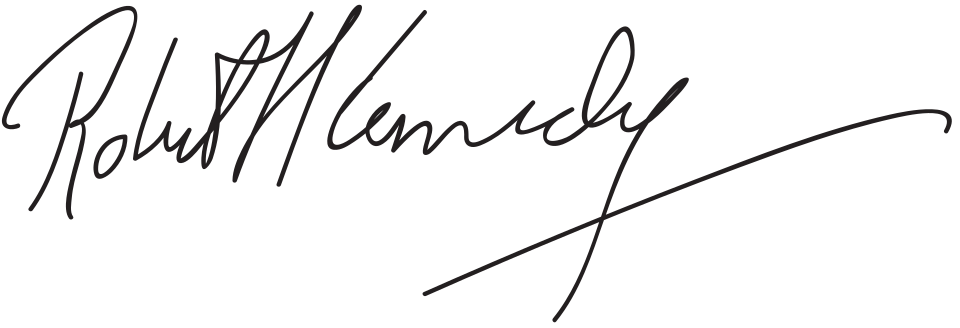


Joseph_McCarthy:


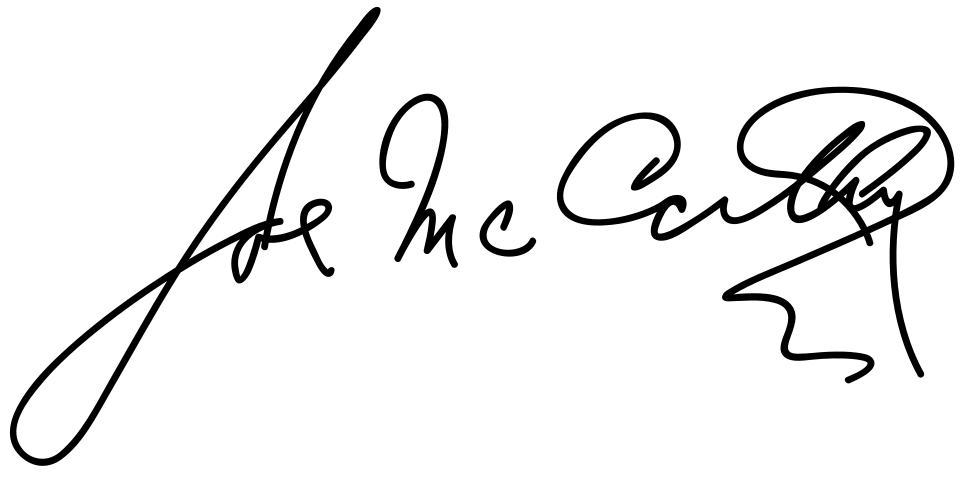


Douglas_MacArthur:


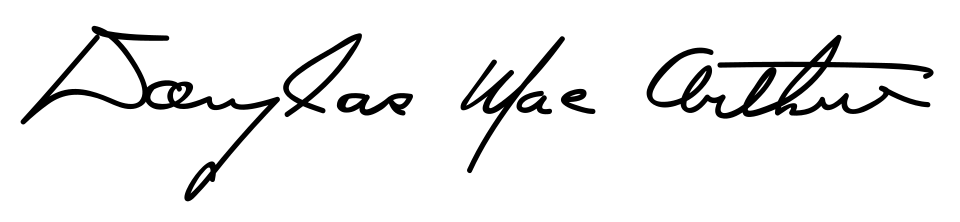


Nicholas_I_of_Russia:


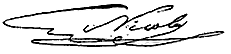


Alexander_I_of_Russia:


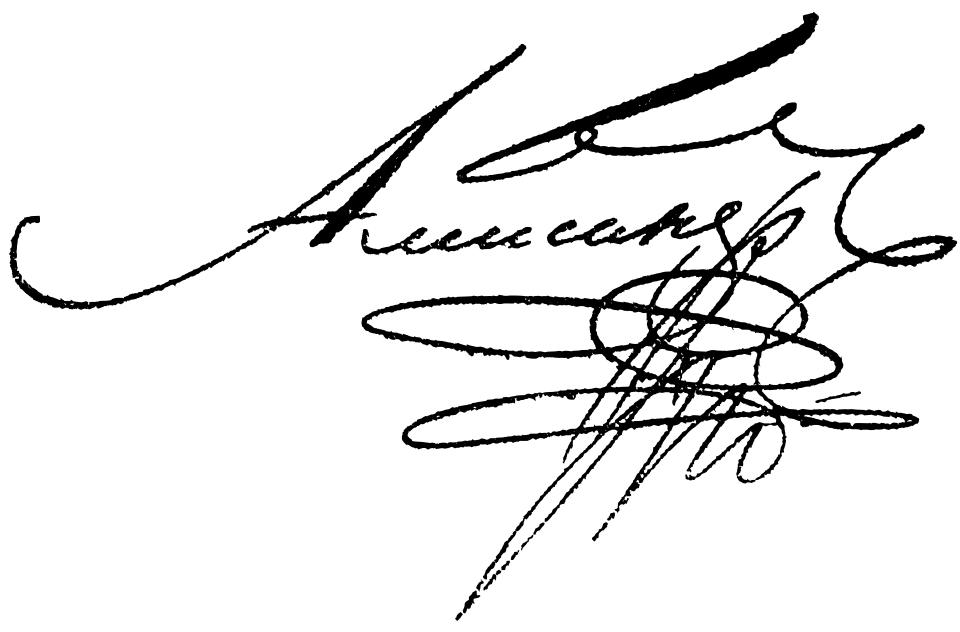


Alexander_II_of_Russia:


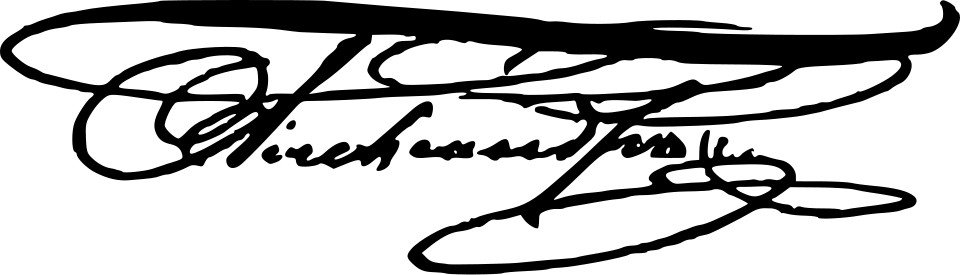


Alexander_III_of_Russia:


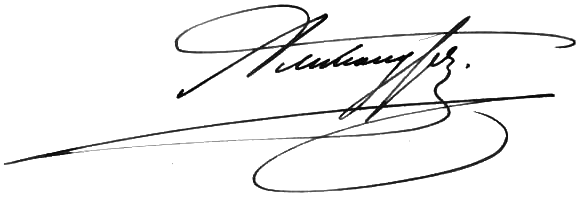


Abraham_Lincoln:


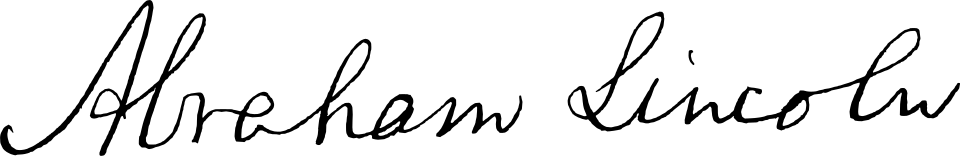


Boris_Yeltsin:


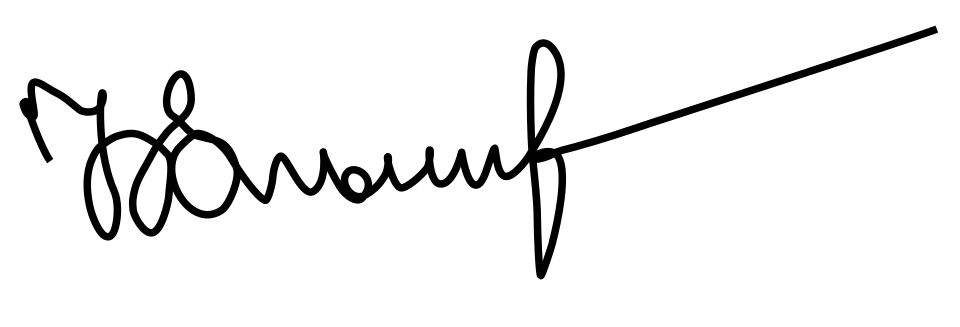


Wernher_von_Braun:


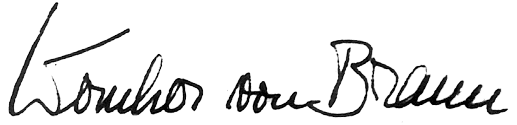


Konstantin_Tsiolkovsky:


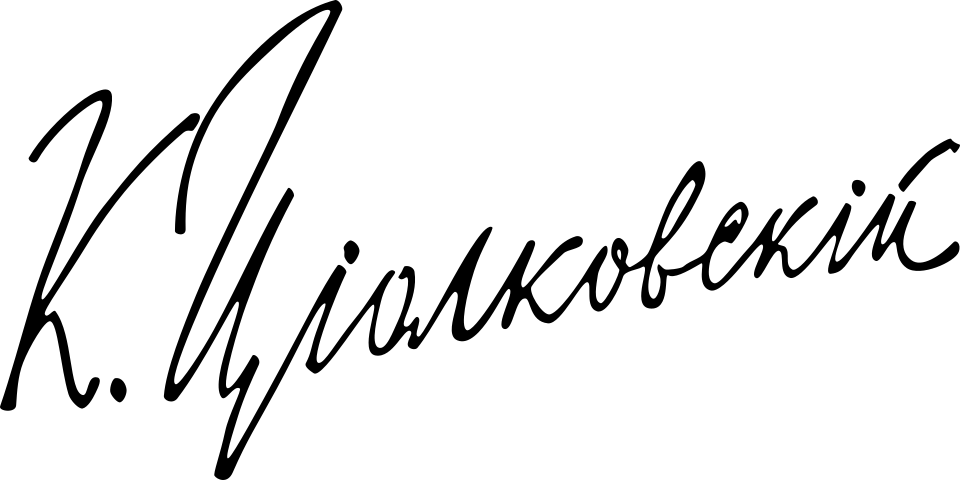


Anton_Chekhov:


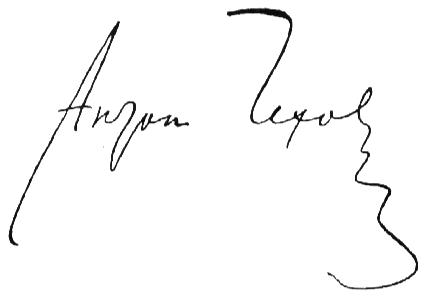


Fyodor_Dostoevsky:


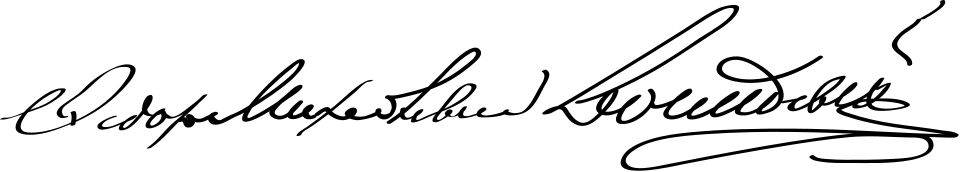


Mikhail_Bulgakov:


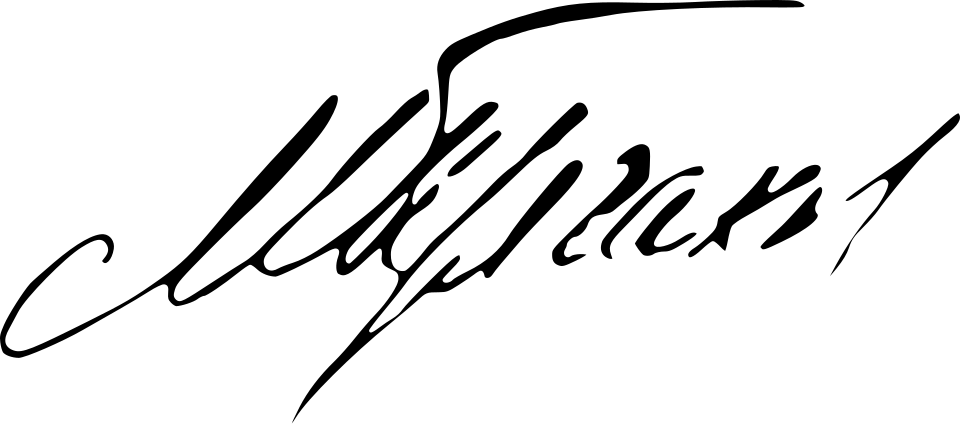


Henry_Ford:


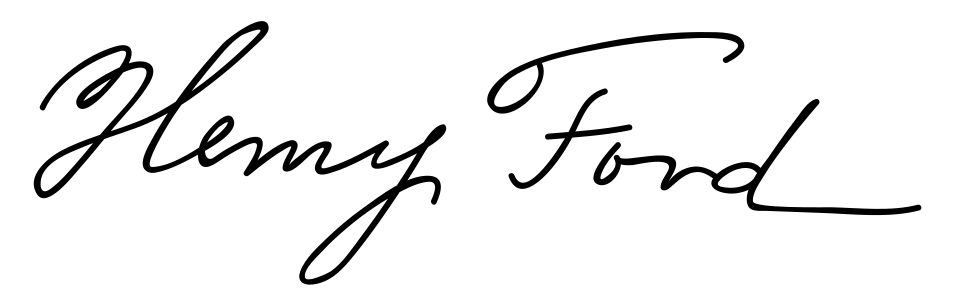


Ferdinand_Porsche:


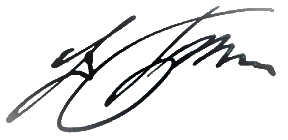


J._Robert_Oppenheimer:


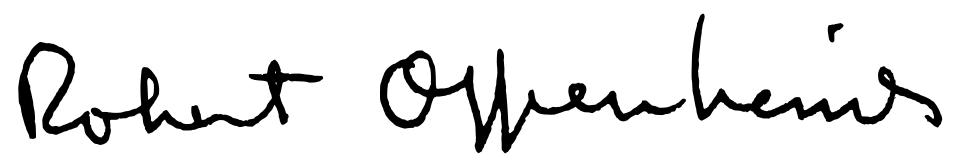


Elon_Musk:


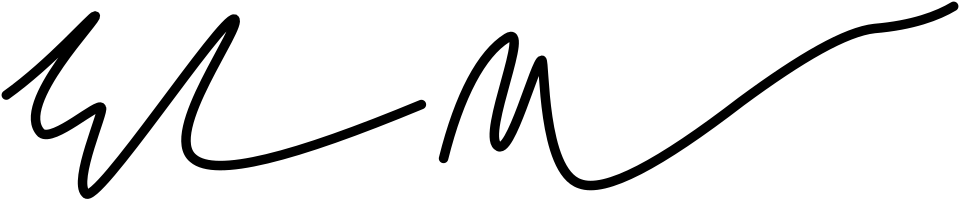


Kurt_Cobain:


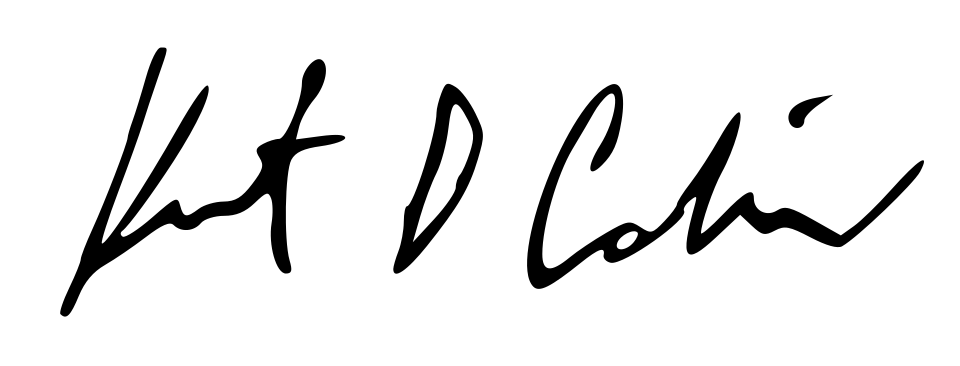


John_Lennon:


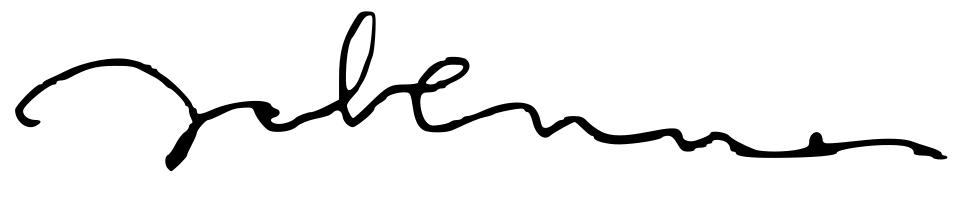


Paul_McCartney:


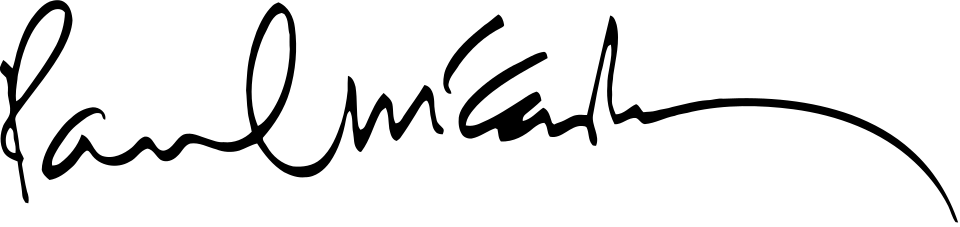


Leon_Trotsky:


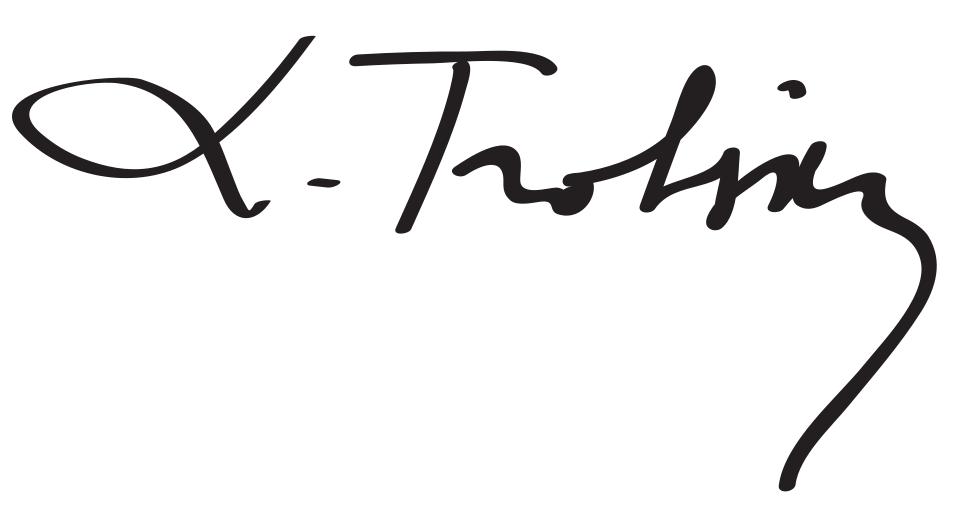


Pyotr_Wrangel:


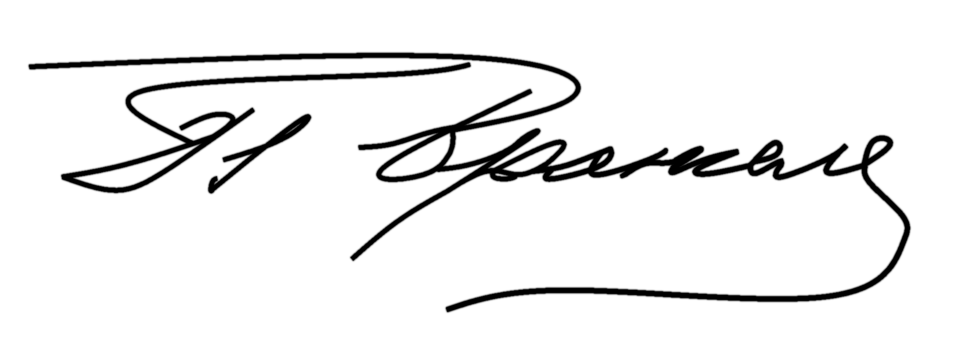


Andrei_Tupolev:


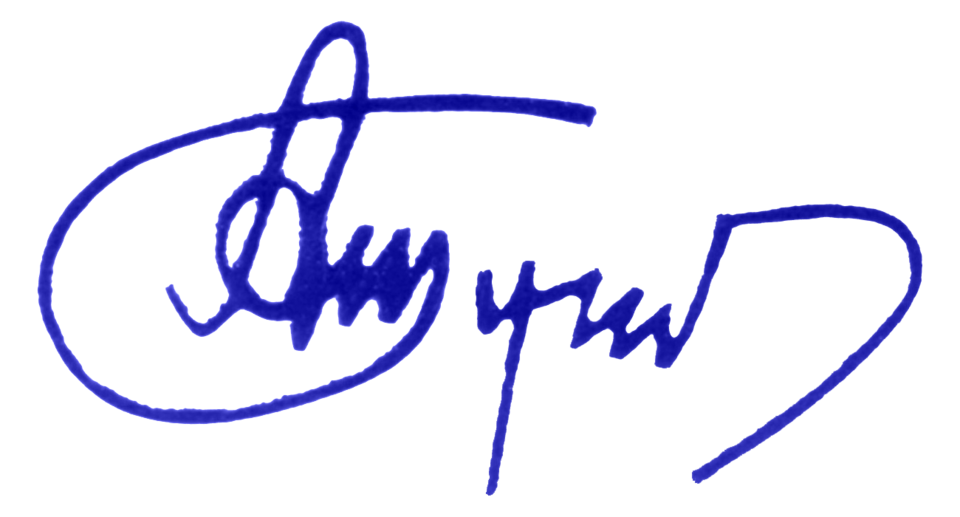


William_E._Boeing:


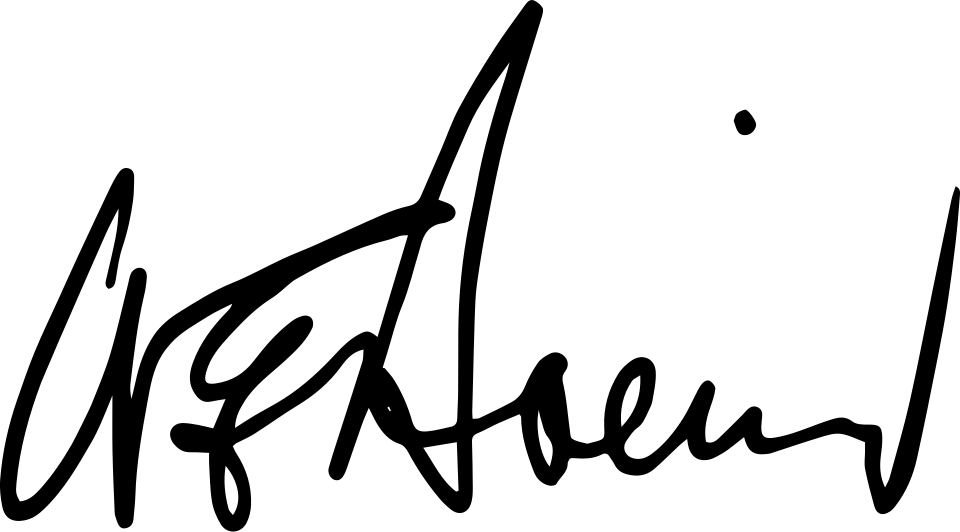


Nikolay_Zhukovsky_(scientist):


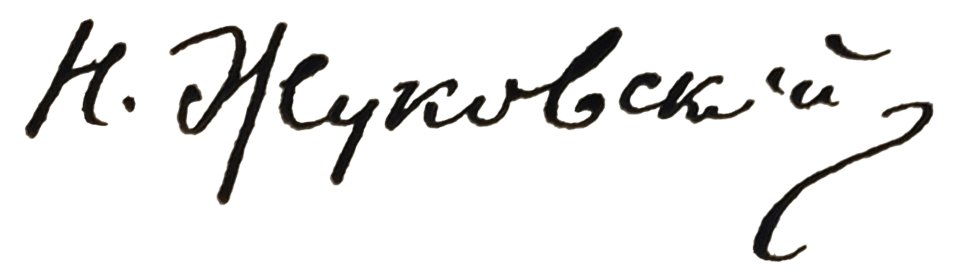


Pafnuty_Chebyshev:


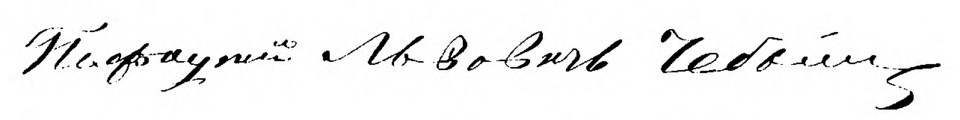


Carl_Gustaf_Emil_Mannerheim:


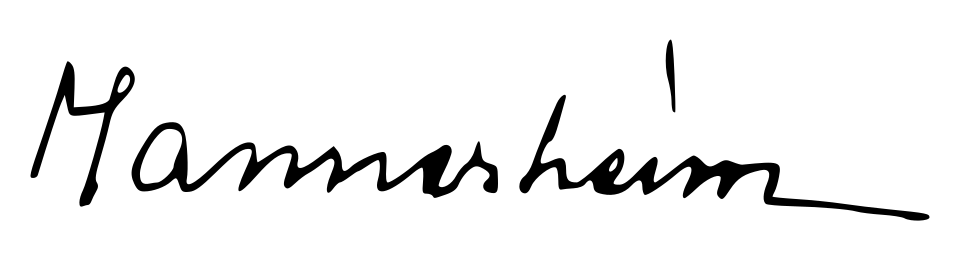


Georgy_Zhukov:


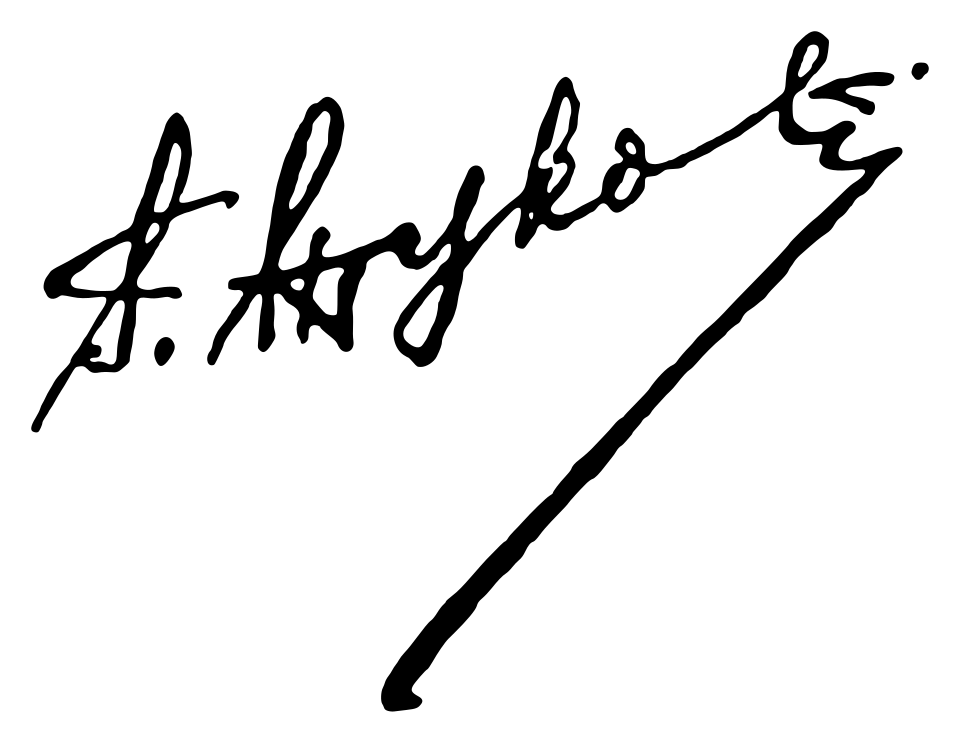


J._R._R._Tolkien:


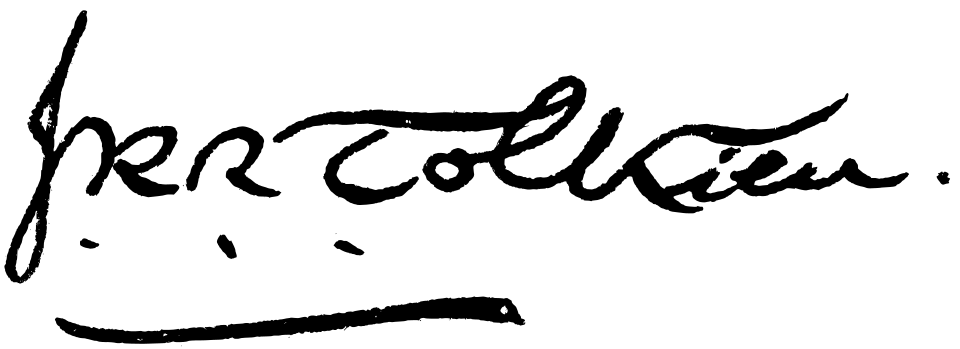


Nikolai_Gogol:


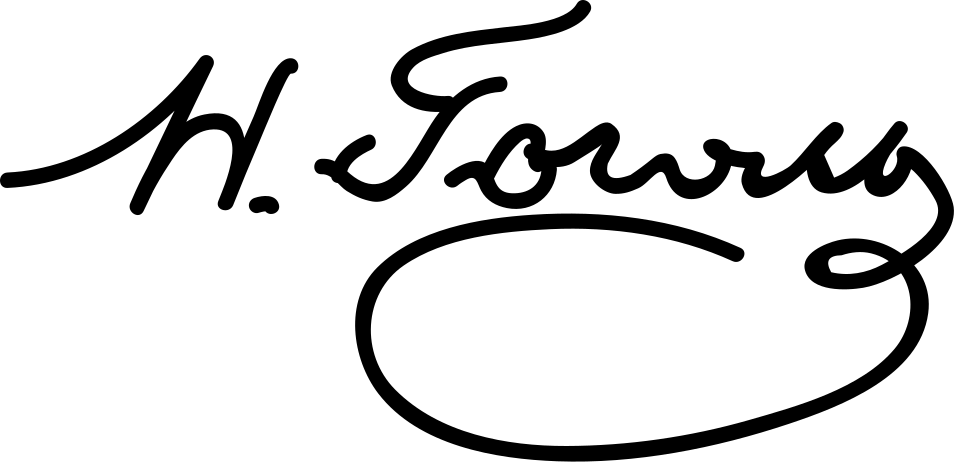


Neil_Armstrong:


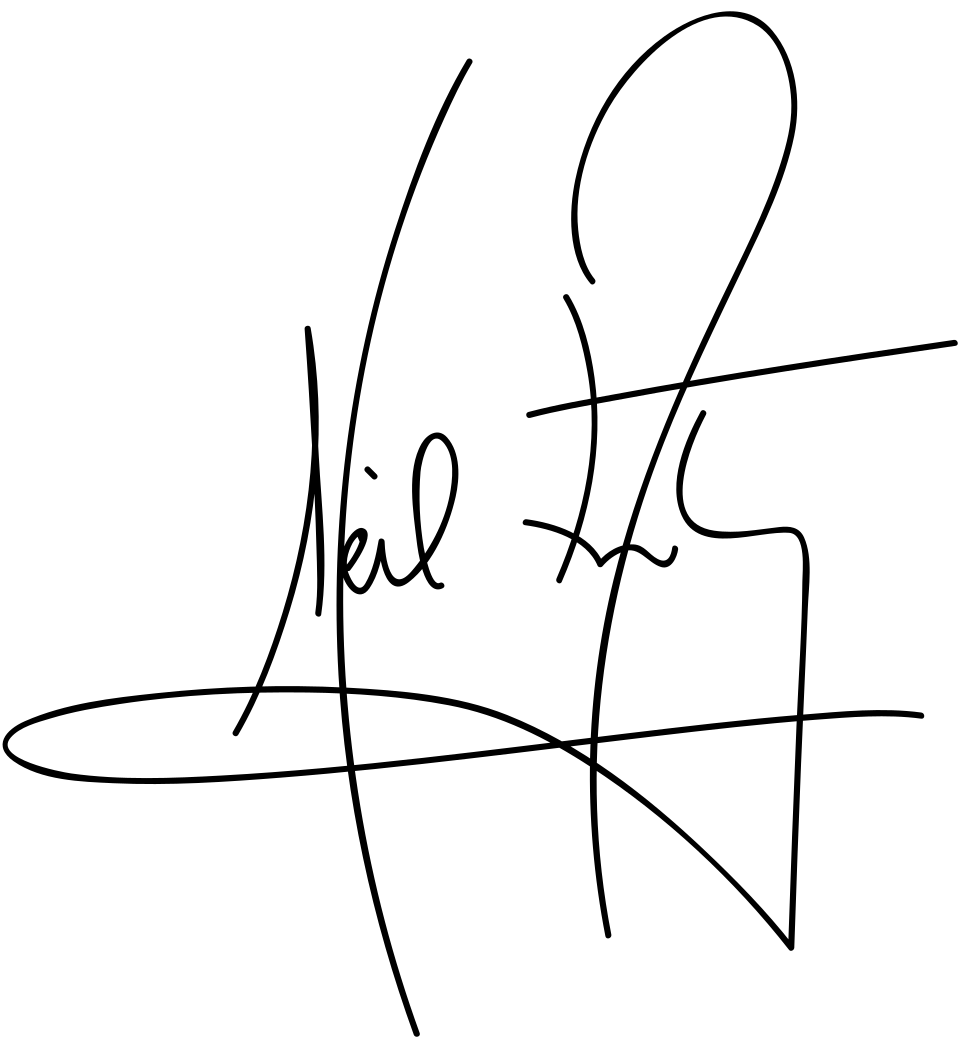


Ozzy_Osbourne:


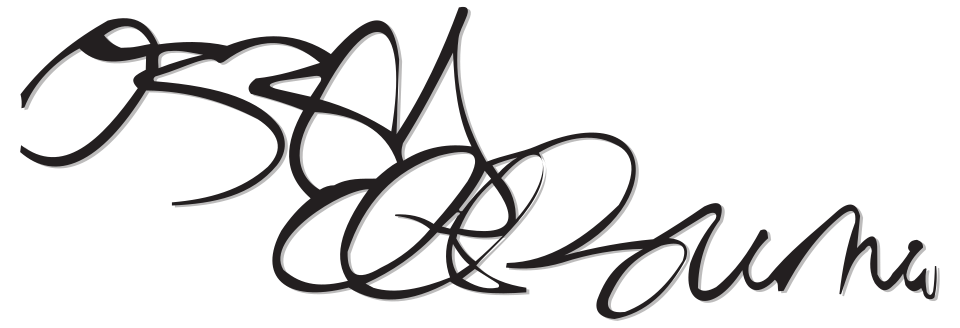

In [ ]:
from IPython.display import Image, display

image_dir = "sigscr_dir_imporved_random/images_png"

# Ensure the 'img' column is treated as a string and handle potential leading/trailing spaces
data["img"] = data["img"].astype(str).str.strip()

print("Displaying signatures:")
for index, row in data.iterrows():
    person_name = row["name"]
    image_filename = row["img"]

    # Check if image_filename is not empty or 'None' (which can happen if no signature was found)
    if image_filename and image_filename != "None":
        image_path = os.path.join(image_dir, image_filename)
        if os.path.exists(image_path):
            print(f"\n{person_name}:")
            display(Image(filename=image_path, width=200))
        else:
            print(f"\nImage not found for {person_name} at {image_path}")
    else:
        print(f"\nNo image filename found for {person_name}")